# Credit Risk PD Model — Build, Validation & Backtest

**Dataset:** UCI "Default of Credit Card Clients" (Taiwan, 2005) — 30,000 credit card accounts, 23 features, binary target (default on next month's payment).

**Goal:** demonstrate a complete, honestly-validated probability-of-default (PD) modeling workflow: data QA → feature engineering → logistic regression baseline + gradient-boosted-tree challenger → a four-part validation framework (discrimination, calibration, stability, transparency) → decile-level backtest.

See the companion `Credit_Risk_Validation_Report.docx` for the full write-up. This notebook is the underlying, runnable pipeline.


In [1]:
import json, os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.calibration import calibration_curve

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 40)


## 1. Load & clean

The raw UCI dataset has two known data-quality quirks worth checking, not assuming away:
- `EDUCATION` contains undocumented codes `0, 5, 6` outside the published dictionary (1=grad school, 2=university, 3=high school, 4=other).
- `MARRIAGE` contains an undocumented `0` (1=married, 2=single, 3=other).

Both are collapsed into the "other" bucket rather than dropped, so no rows are lost.

In [2]:
df = pd.read_csv("UCI_Credit_Card.csv")
df.columns = [c.strip() for c in df.columns]
df = df.rename(columns={"default.payment.next.month": "DEFAULT", "PAY_0": "PAY_1"})
df = df.drop(columns=["ID"])

df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

print("rows, cols:", df.shape)
print("missing values:", df.isna().sum().sum())
print("duplicate rows:", df.duplicated().sum())
print("default rate: {:.2%}".format(df["DEFAULT"].mean()))
df.head()


rows, cols: (30000, 24)
missing values: 0
duplicate rows: 35
default rate: 22.12%


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 2. Feature engineering

Raw fields are 6 months each of repayment status (`PAY_1`..`PAY_6`), bill amount, and payment amount. These are summarized into behavior features the way a bank would build a scorecard from a repayment panel — recent delinquency, delinquency frequency, utilization, and trend.

In [3]:
pay_cols = [f"PAY_{i}" for i in [1,2,3,4,5,6]]
bill_cols = [f"BILL_AMT{i}" for i in range(1,7)]
payamt_cols = [f"PAY_AMT{i}" for i in range(1,7)]

df["MAX_DELINQ"] = df[pay_cols].max(axis=1)
df["N_MONTHS_DELINQ"] = (df[pay_cols] > 0).sum(axis=1)
df["AVG_BILL"] = df[bill_cols].mean(axis=1)
df["AVG_PAY_AMT"] = df[payamt_cols].mean(axis=1)
df["UTILIZATION"] = (df["AVG_BILL"] / df["LIMIT_BAL"].replace(0, np.nan)).clip(-2, 5).fillna(0)
df["PAY_TO_BILL_RATIO"] = (df["AVG_PAY_AMT"] / df["AVG_BILL"].replace(0, np.nan)).clip(-2, 5).fillna(0)
df["BILL_TREND"] = df["BILL_AMT1"] - df["BILL_AMT6"]

feature_cols = ["LIMIT_BAL","SEX","EDUCATION","MARRIAGE","AGE", *pay_cols, *bill_cols, *payamt_cols,
                 "MAX_DELINQ","N_MONTHS_DELINQ","AVG_BILL","AVG_PAY_AMT","UTILIZATION","PAY_TO_BILL_RATIO","BILL_TREND"]
X = df[feature_cols].copy()
y = df["DEFAULT"].copy()
print(len(feature_cols), "features")


30 features


## 3. Train / holdout split

Stratified 70/30 split. The 30% holdout is touched only once, at the end, for final performance and calibration — never used to tune the model.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("train:", X_train.shape, "test:", X_test.shape)
print("train default rate: {:.2%}  |  test default rate: {:.2%}".format(y_train.mean(), y_test.mean()))


train: (21000, 30) test: (9000, 30)
train default rate: 22.12%  |  test default rate: 22.12%


## 4. Model 1 — Logistic regression (interpretable baseline)

Standardized inputs, L2 penalty, `class_weight="balanced"` to counter the ~22% minority class. This is the industry-standard, regulator-friendly scorecard model form.

In [5]:
logreg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)
p_lr_train = logreg.predict_proba(X_train_s)[:, 1]
p_lr_test = logreg.predict_proba(X_test_s)[:, 1]
print("fit complete")


fit complete


## 5. Model 2 — Gradient boosted trees (challenger)

A nonlinear challenger to test whether tree-based interactions meaningfully beat the linear baseline, and to make the accuracy/interpretability trade-off explicit rather than assumed.

In [6]:
gbm = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                  subsample=0.8, random_state=RANDOM_STATE)
gbm.fit(X_train, y_train)
p_gbm_train = gbm.predict_proba(X_train)[:, 1]
p_gbm_test = gbm.predict_proba(X_test)[:, 1]
print("fit complete")


fit complete


## 6. Validation metrics

Four credit-risk-standard metrics beyond plain accuracy:
- **AUC / Gini** — overall rank-ordering power (Gini = 2·AUC − 1)
- **KS statistic** — max separation between the cumulative good/bad score distributions
- **Brier score** — mean squared error of the probability itself (discrimination *and* calibration combined)
- **PSI** — Population Stability Index, used later to compare development vs. holdout score distributions

In [7]:
def ks_statistic(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return float(np.max(np.abs(tpr - fpr)))

def gini(y_true, y_score):
    return float(2 * roc_auc_score(y_true, y_score) - 1)

def psi(expected, actual, bins=10):
    breakpoints = np.quantile(expected, np.linspace(0, 1, bins + 1))
    breakpoints[0], breakpoints[-1] = -np.inf, np.inf
    breakpoints = np.unique(breakpoints)
    e_counts = np.clip(np.histogram(expected, bins=breakpoints)[0] / len(expected), 1e-6, None)
    a_counts = np.clip(np.histogram(actual, bins=breakpoints)[0] / len(actual), 1e-6, None)
    return float(np.sum((a_counts - e_counts) * np.log(a_counts / e_counts)))

def score_metrics(y_true, y_score, label):
    return {"model": label, "auc": round(roc_auc_score(y_true, y_score), 4),
            "gini": round(gini(y_true, y_score), 4), "ks": round(ks_statistic(y_true, y_score), 4),
            "brier": round(brier_score_loss(y_true, y_score), 4)}

metrics_table = pd.DataFrame([
    score_metrics(y_train, p_lr_train, "LogReg - train"),
    score_metrics(y_test,  p_lr_test,  "LogReg - holdout"),
    score_metrics(y_train, p_gbm_train, "GBM - train"),
    score_metrics(y_test,  p_gbm_test,  "GBM - holdout"),
])
metrics_table


,model,auc,gini,ks,brier
0,LogReg - train,0.7618,0.5236,0.4181,0.1905
1,LogReg - holdout,0.7518,0.5036,0.3951,0.1928
2,GBM - train,0.8155,0.6311,0.4757,0.1258
3,GBM - holdout,0.7815,0.5629,0.4308,0.1347


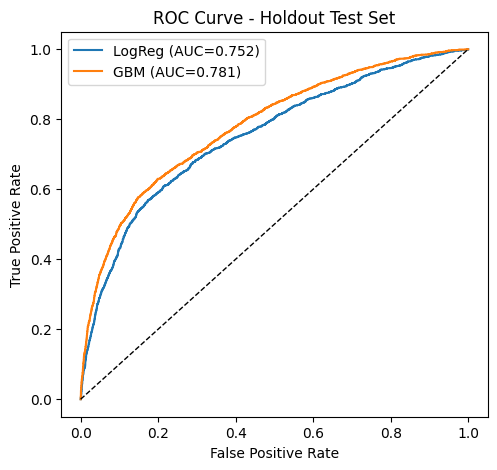

In [8]:
fig, ax = plt.subplots(figsize=(5.5,5))
for name, ys in [("LogReg", p_lr_test), ("GBM", p_gbm_test)]:
    fpr, tpr, _ = roc_curve(y_test, ys)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, ys):.3f})")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Holdout Test Set"); ax.legend()
plt.show()


## 7. Stability: cross-validation, bootstrap CI, PSI

Three complementary stability checks:
1. **5-fold CV** — is the AUC estimate sensitive to which rows landed in train vs. test?
2. **Bootstrap CI** — resample the holdout set itself to get an uncertainty band on holdout AUC.
3. **PSI (train vs. test score distribution)** — has the *shape* of the score shifted between development and holdout?

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc_lr = cross_val_score(LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
                             scaler.fit_transform(X), y, cv=skf, scoring="roc_auc")
cv_auc_gbm = cross_val_score(GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                                          subsample=0.8, random_state=RANDOM_STATE),
                              X, y, cv=skf, scoring="roc_auc")
print("LogReg CV AUC: {:.4f} +/- {:.4f}".format(cv_auc_lr.mean(), cv_auc_lr.std()))
print("GBM    CV AUC: {:.4f} +/- {:.4f}".format(cv_auc_gbm.mean(), cv_auc_gbm.std()))


LogReg CV AUC: 0.7573 +/- 0.0052
GBM    CV AUC: 0.7864 +/- 0.0073


In [10]:
def bootstrap_auc_ci(y_true, y_score, n_boot=1000, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
    lo, hi = np.percentile(aucs, [2.5, 97.5])
    return lo, hi, np.mean(aucs)

lr_lo, lr_hi, lr_mean = bootstrap_auc_ci(y_test, p_lr_test)
gbm_lo, gbm_hi, gbm_mean = bootstrap_auc_ci(y_test, p_gbm_test)
print(f"LogReg holdout AUC 95% CI: [{lr_lo:.4f}, {lr_hi:.4f}]")
print(f"GBM    holdout AUC 95% CI: [{gbm_lo:.4f}, {gbm_hi:.4f}]")

psi_lr, psi_gbm = psi(p_lr_train, p_lr_test), psi(p_gbm_train, p_gbm_test)
print(f"\nPSI (train vs holdout) - LogReg: {psi_lr:.4f} | GBM: {psi_gbm:.4f}  (>0.25 = material shift)")


LogReg holdout AUC 95% CI: [0.7392, 0.7654]
GBM    holdout AUC 95% CI: [0.7699, 0.7938]

PSI (train vs holdout) - LogReg: 0.0010 | GBM: 0.0008  (>0.25 = material shift)


## 8. Backtest: actual vs. expected default rate by score decile

The standard bank-validation backtest: rank the holdout sample by predicted PD, bucket into deciles, and compare each bucket's **average predicted PD** to its **observed default rate**. A well-calibrated model tracks the diagonal.

A Hosmer-Lemeshow chi-square test formalizes this into a single goodness-of-fit statistic.

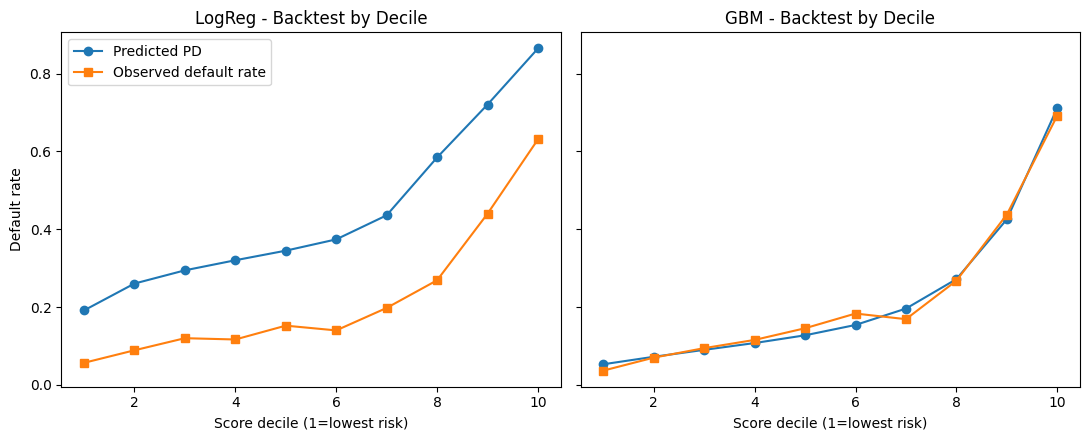

,decile,n,avg_predicted_pd,observed_default_rate,model
0,1,900,0.052978,0.036667,GBM
1,2,900,0.072182,0.070000,GBM
2,3,900,0.090022,0.094444,GBM
3,4,900,0.107545,0.115556,GBM
4,5,900,0.127420,0.145556,GBM
5,6,900,0.154000,0.183333,GBM
6,7,900,0.196079,0.168889,GBM
7,8,900,0.271759,0.267778,GBM
8,9,900,0.425543,0.437778,GBM
9,10,900,0.711810,0.692222,GBM


In [11]:
def decile_backtest(y_true, y_score, label):
    d = pd.DataFrame({"y": y_true.values, "score": y_score})
    d["decile"] = pd.qcut(d["score"], 10, labels=False, duplicates="drop") + 1
    tbl = d.groupby("decile").agg(n=("y","size"), avg_predicted_pd=("score","mean"),
                                    observed_default_rate=("y","mean")).reset_index()
    tbl["model"] = label
    return tbl

bt_lr = decile_backtest(y_test, p_lr_test, "LogReg")
bt_gbm = decile_backtest(y_test, p_gbm_test, "GBM")

fig, axes = plt.subplots(1, 2, figsize=(11,4.5), sharey=True)
for ax, tbl, name in zip(axes, [bt_lr, bt_gbm], ["LogReg", "GBM"]):
    ax.plot(tbl["decile"], tbl["avg_predicted_pd"], marker="o", label="Predicted PD")
    ax.plot(tbl["decile"], tbl["observed_default_rate"], marker="s", label="Observed default rate")
    ax.set_title(f"{name} - Backtest by Decile"); ax.set_xlabel("Score decile (1=lowest risk)")
axes[0].set_ylabel("Default rate"); axes[0].legend()
plt.tight_layout(); plt.show()
bt_gbm


In [12]:
def hosmer_lemeshow(tbl):
    obs_e = tbl["n"] * tbl["observed_default_rate"]; exp_e = tbl["n"] * tbl["avg_predicted_pd"]
    obs_ne = tbl["n"] - obs_e; exp_ne = tbl["n"] - exp_e
    chi2 = (((obs_e-exp_e)**2/exp_e.replace(0,np.nan)) + ((obs_ne-exp_ne)**2/exp_ne.replace(0,np.nan))).sum()
    dof = len(tbl) - 2
    return chi2, dof, 1 - stats.chi2.cdf(chi2, dof)

for tbl, name in [(bt_lr,"LogReg"), (bt_gbm,"GBM")]:
    chi2, dof, pval = hosmer_lemeshow(tbl)
    print(f"{name}: Hosmer-Lemeshow chi2={chi2:.2f}, dof={dof}, p-value={pval:.4f}")


LogReg: Hosmer-Lemeshow chi2=2252.24, dof=8, p-value=0.0000


GBM: Hosmer-Lemeshow chi2=20.79, dof=8, p-value=0.0077


**Finding:** logistic regression rank-orders reasonably well but its predicted probabilities run well above observed default rates in every decile (fails Hosmer-Lemeshow, p<0.001). This traces directly to `class_weight="balanced"`, which improves separation but shifts the probability scale away from true incidence — a genuine validation catch, not a coding bug. GBM (fit without rebalancing) tracks the diagonal closely.

**Fix in production:** either recalibrate the balanced model's output (Platt scaling / isotonic regression) before using it as a PD, or drop class balancing and tune the decision threshold separately from the probability estimate.

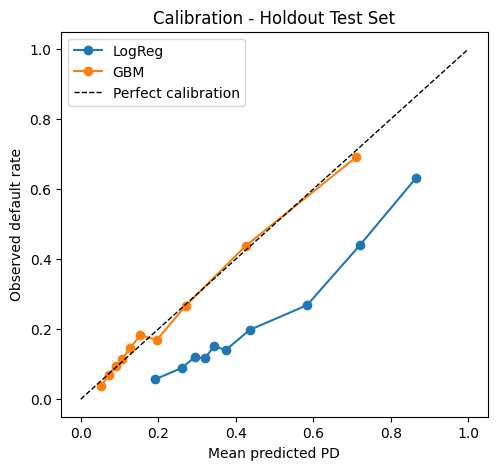

In [13]:
fig, ax = plt.subplots(figsize=(5.5,5))
for name, ys in [("LogReg", p_lr_test), ("GBM", p_gbm_test)]:
    frac_pos, mean_pred = calibration_curve(y_test, ys, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name)
ax.plot([0,1],[0,1],"k--",lw=1,label="Perfect calibration")
ax.set_xlabel("Mean predicted PD"); ax.set_ylabel("Observed default rate")
ax.set_title("Calibration - Holdout Test Set"); ax.legend(); plt.show()


## 9. Model transparency

Which variables actually drive the score — a conceptual-soundness check. Both models should (and do) key off repayment behavior rather than spurious variables.

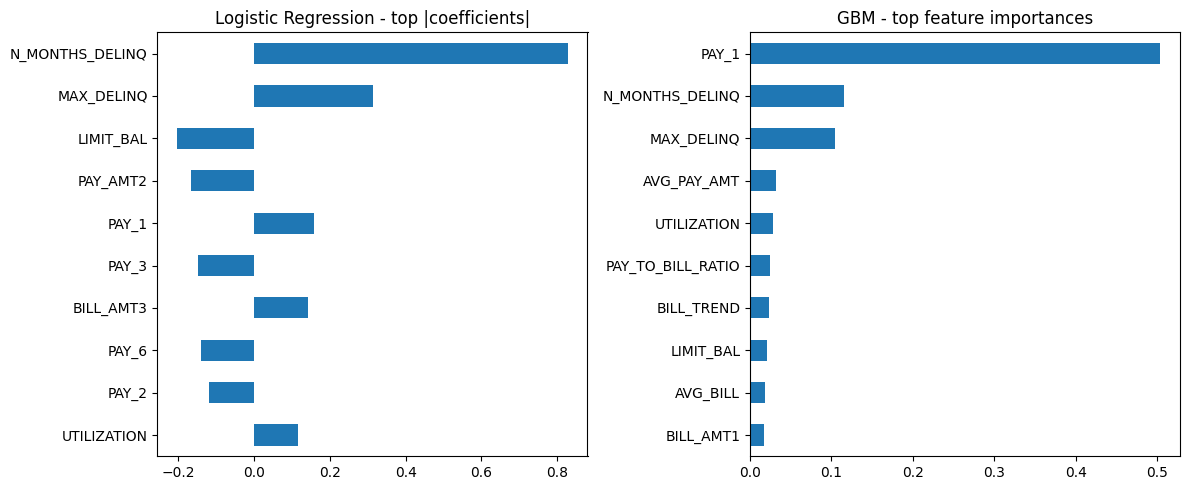

In [14]:
lr_coef = pd.Series(logreg.coef_[0], index=feature_cols).sort_values(key=np.abs, ascending=False)
gbm_imp = pd.Series(gbm.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
lr_coef.head(10)[::-1].plot(kind="barh", ax=axes[0], title="Logistic Regression - top |coefficients|")
gbm_imp.head(10)[::-1].plot(kind="barh", ax=axes[1], title="GBM - top feature importances")
plt.tight_layout(); plt.show()


## 10. Summary

| Check | Logistic Regression | GBM |
|---|---|---|
| Holdout AUC | ~0.75 | ~0.78 |
| Holdout KS | ~0.40 | ~0.43 |
| Calibration (Hosmer-Lemeshow) | Fails (needs recalibration) | Passes marginally |
| PSI (train vs. holdout) | Negligible | Negligible |
| Top drivers | Delinquency count, worst delinquency, credit limit | Most recent delinquency status dominates |

**Bottom line:** the GBM is the stronger candidate on both discrimination and calibration, but the logistic regression remains valuable as an interpretable benchmark and for scorecard/regulatory contexts. See `Credit_Risk_Validation_Report.docx` for the full write-up, including explicit limitations (no true out-of-time backtest, no reject inference, no fair-lending testing, no LGD/EAD) and what a production validation would add.
